# 04 - Where does the model get it wrong?

1. Build a confusion matrix - what kinds of mistakes does the model actually make?
2. Look at precision and recall separately - which mistake does the model make more?
3. Subgroup analysis - does the model work equally well for every kind of customer, or does it
   quietly perform worse for some groups than others?

## Step 1: Get the data and train the final model

In [1]:
import sys, warnings
sys.path.append('..')
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

from src.setup import prepare_everything
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

X_train, X_test, y_train, y_test, preprocessing, cv = prepare_everything()

# the winner from notebook 03: Logistic Regression, tuned to C=100
final_model = Pipeline([
    ('preprocessing', preprocessing),
    ('model', LogisticRegression(C=100, max_iter=1000, random_state=42)),
])
final_model.fit(X_train, y_train)

test_predictions = final_model.predict(X_test)
test_probabilities = final_model.predict_proba(X_test)[:, 1]

print('Model trained. Predictions made on the held-out test set.')

Model trained. Predictions made on the held-out test set.


## Step 2: Confusion matrix
A confusion matrix sorts every test prediction into one of four boxes:

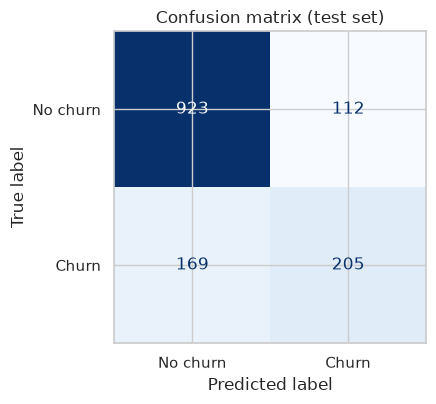

Correct  (no churn):   923
False alarms:          112
Missed churners:       169
Correct  (churn):      205


In [2]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, test_predictions)

fig, ax = plt.subplots(figsize=(4.5, 4.2))
disp = ConfusionMatrixDisplay(cm, display_labels=['No churn', 'Churn'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title('Confusion matrix (test set)')
plt.tight_layout()
plt.savefig('../figures/confusion_matrix.png', dpi=150)
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'Correct  (no churn):   {tn}')
print(f'False alarms:          {fp}')
print(f'Missed churners:       {fn}')
print(f'Correct  (churn):      {tp}')

## Step 3: Precision and recall
- **Precision** (for the "churn" class): out of everyone the model FLAGGED as a churn risk, what
  percentage actually churned? Low precision means a lot of wasted retention offers.
- **Recall** (for the "churn" class): out of everyone who ACTUALLY churned, what percentage did the
  model catch? Low recall means a lot of missed churners - the more expensive mistake, as above.

In [3]:
from sklearn.metrics import classification_report

print(classification_report(y_test, test_predictions, target_names=['No churn', 'Churn']))

              precision    recall  f1-score   support

    No churn       0.85      0.89      0.87      1035
       Churn       0.65      0.55      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.79      0.80      0.80      1409



For the Churn row specifically:

Recall = 0.55, or 55%.

This means the model is correctly catching 55% of the customers who actually churn. In other words, it is missing about 45% of the actual churners.

For a phone company, missing almost half of the customers who are going to leave could be costly because the company loses the opportunity to try to retain them

## Step 4: Does the model work equally well for every subgroup?

In [4]:
# put the test set predictions together with the actual subgroup columns, so we can group by them
results_df = X_test.copy()
results_df['actual'] = y_test.values
results_df['predicted'] = test_predictions
results_df['correct'] = (results_df['actual'] == results_df['predicted'])

# group tenure into bands, since "tenure = 37" on its own isn't a subgroup - a RANGE of tenure is
results_df['tenure_band'] = pd.cut(
    results_df['tenure'],
    bins=[-1, 12, 24, 48, 100],
    labels=['0-12 months', '13-24 months', '25-48 months', '49+ months'],
)

print('Subgroup columns ready.')

Subgroup columns ready.


In [5]:
from sklearn.metrics import f1_score, recall_score

def scores_by_group(column_name):
    """For each value in a subgroup column, compute how many test customers are in it,
    and the F1 and recall the model gets JUST on that group."""
    rows = []
    for group_value in results_df[column_name].dropna().unique():
        subset = results_df[results_df[column_name] == group_value]
        rows.append({
            column_name: group_value,
            'customers in group': len(subset),
            'actual churn rate': round(subset['actual'].mean(), 3),
            'F1 for this group': round(f1_score(subset['actual'], subset['predicted']), 3),
            'recall for this group': round(recall_score(subset['actual'], subset['predicted']), 3),
        })
    return pd.DataFrame(rows).sort_values('F1 for this group')

contract_scores = scores_by_group('Contract')
contract_scores

,Contract,customers in group,actual churn rate,F1 for this group,recall for this group
0,Two year,336,0.027,0.000,0.000
2,One year,300,0.120,0.000,0.000
1,Month-to-month,773,0.426,0.637,0.623


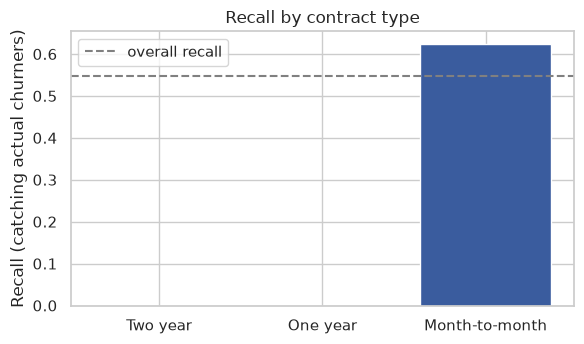

In [6]:
plt.figure(figsize=(6, 3.6))
plt.bar(contract_scores['Contract'], contract_scores['recall for this group'], color='#3a5c9e')
plt.axhline(recall_score(results_df['actual'], results_df['predicted']), color='grey', linestyle='--',
            label='overall recall')
plt.ylabel('Recall (catching actual churners)')
plt.title('Recall by contract type')
plt.legend()
plt.tight_layout()
plt.savefig('../figures/recall_by_contract.png', dpi=150)
plt.show()

In [7]:
senior_scores = scores_by_group('SeniorCitizen')
senior_scores

,SeniorCitizen,customers in group,actual churn rate,F1 for this group,recall for this group
0,0,1187,0.233,0.570,0.518
1,1,222,0.441,0.656,0.633


In [8]:
tenure_scores = scores_by_group('tenure_band')
tenure_scores

,tenure_band,customers in group,actual churn rate,F1 for this group,recall for this group
0,49+ months,450,0.078,0.108,0.057
2,25-48 months,304,0.211,0.416,0.328
3,13-24 months,206,0.291,0.619,0.650
1,0-12 months,449,0.479,0.670,0.665


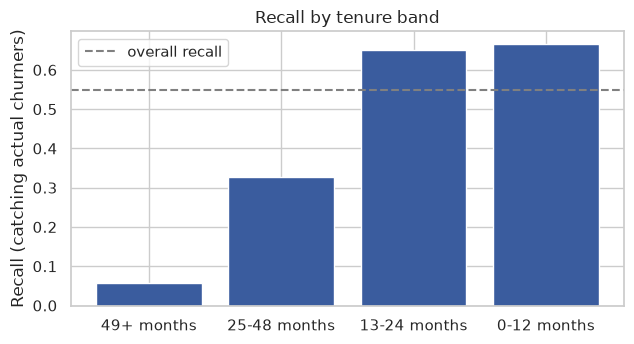

In [9]:
plt.figure(figsize=(6.5, 3.6))
plt.bar(tenure_scores['tenure_band'].astype(str), tenure_scores['recall for this group'], color='#3a5c9e')
plt.axhline(recall_score(results_df['actual'], results_df['predicted']), color='grey', linestyle='--',
            label='overall recall')
plt.ylabel('Recall (catching actual churners)')
plt.title('Recall by tenure band')
plt.legend()
plt.tight_layout()
plt.savefig('../figures/recall_by_tenure.png', dpi=150)
plt.show()